In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# dataset url = https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

data = '../data/raw/creditcard.csv'

df = pd.read_csv(data)


# Show basic info
print("df dimention: ", df.shape)
print("df class distribution: ", df["Class"].value_counts()) # Class distribution
df.info()

df dimention:  (284807, 31)
df class distribution:  Class
0    284315
1       492
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  fl

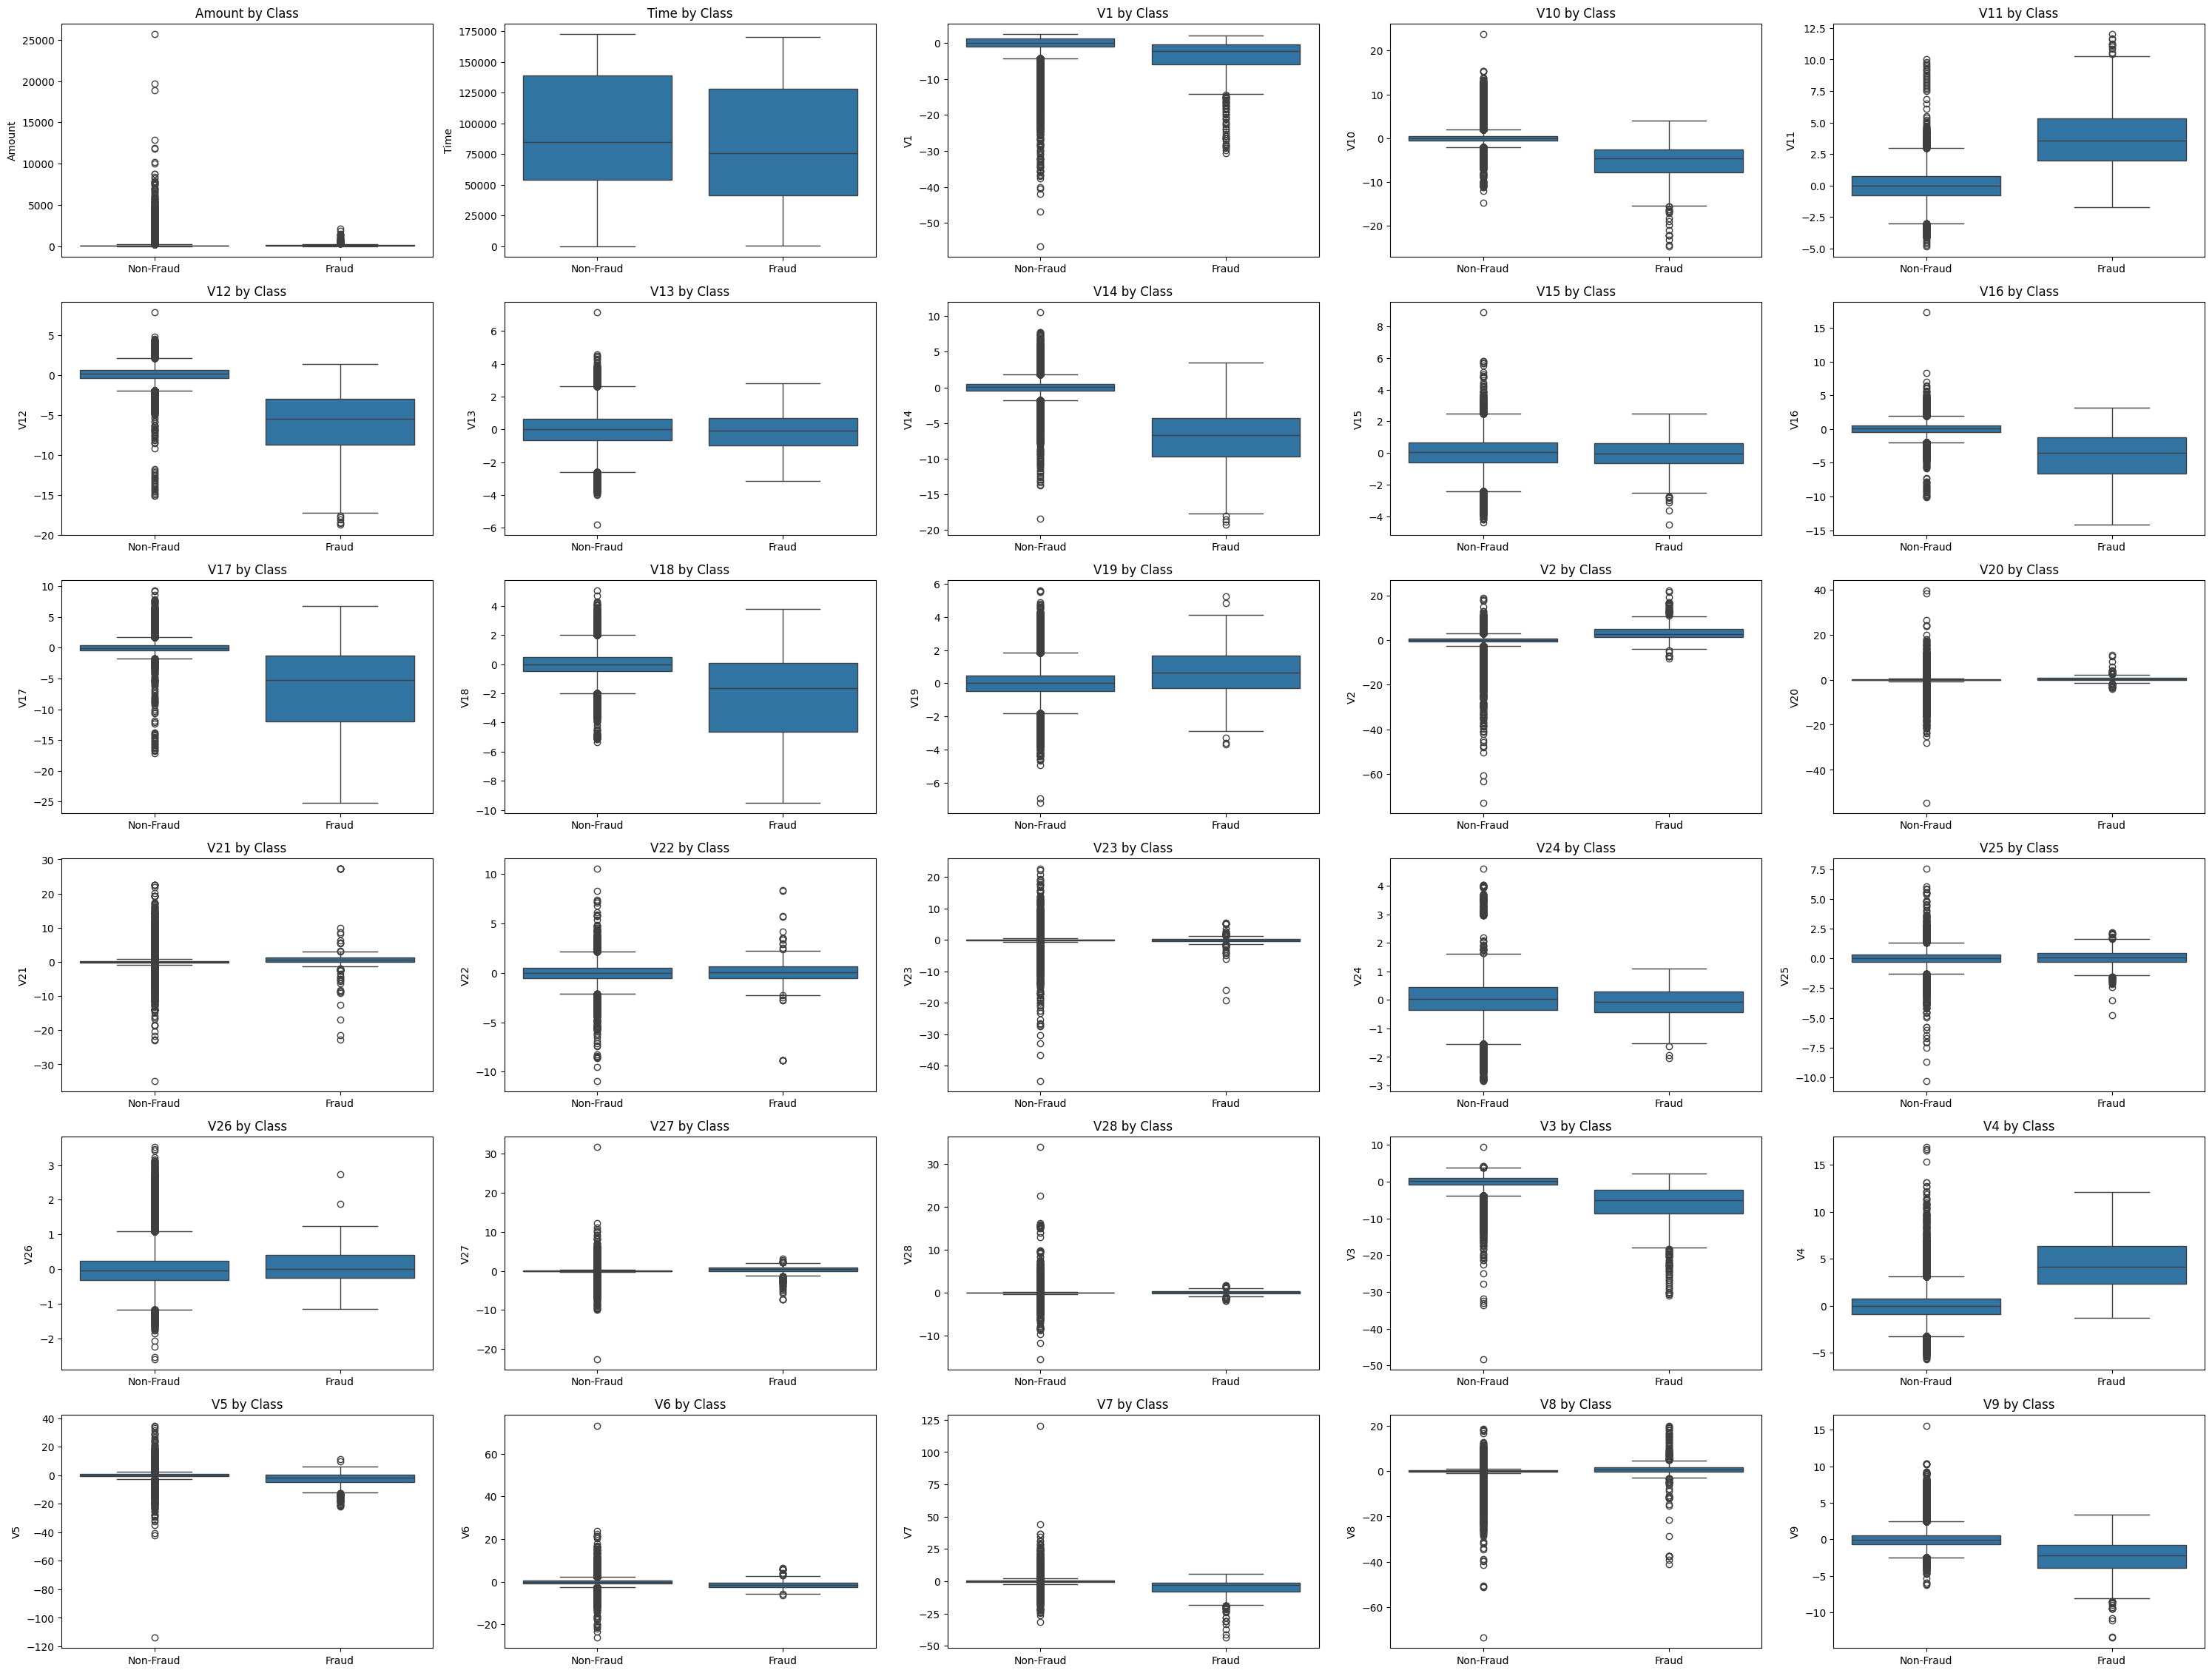

In [ ]:
# Get feature names
target = ['Class']
feature_names = df.columns.difference(target)

# map class labels for readability
df["Class_Label"] = df["Class"].map({0: "Non-Fraud", 1: "Fraud"}) ## Class – binary label: 0 = genuine ; 1 = fraud

n_cols = 4
n_rows = 8

# Create boxplots
plt.figure(figsize=(30, 30))

for i, feature in enumerate(feature_names, 0):
    plt.subplot(8 ,5, i+1)
    sns.boxplot(x="Class_Label", y=feature, data=df)
    plt.title(f"{feature} by Class")
    plt.xlabel("")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

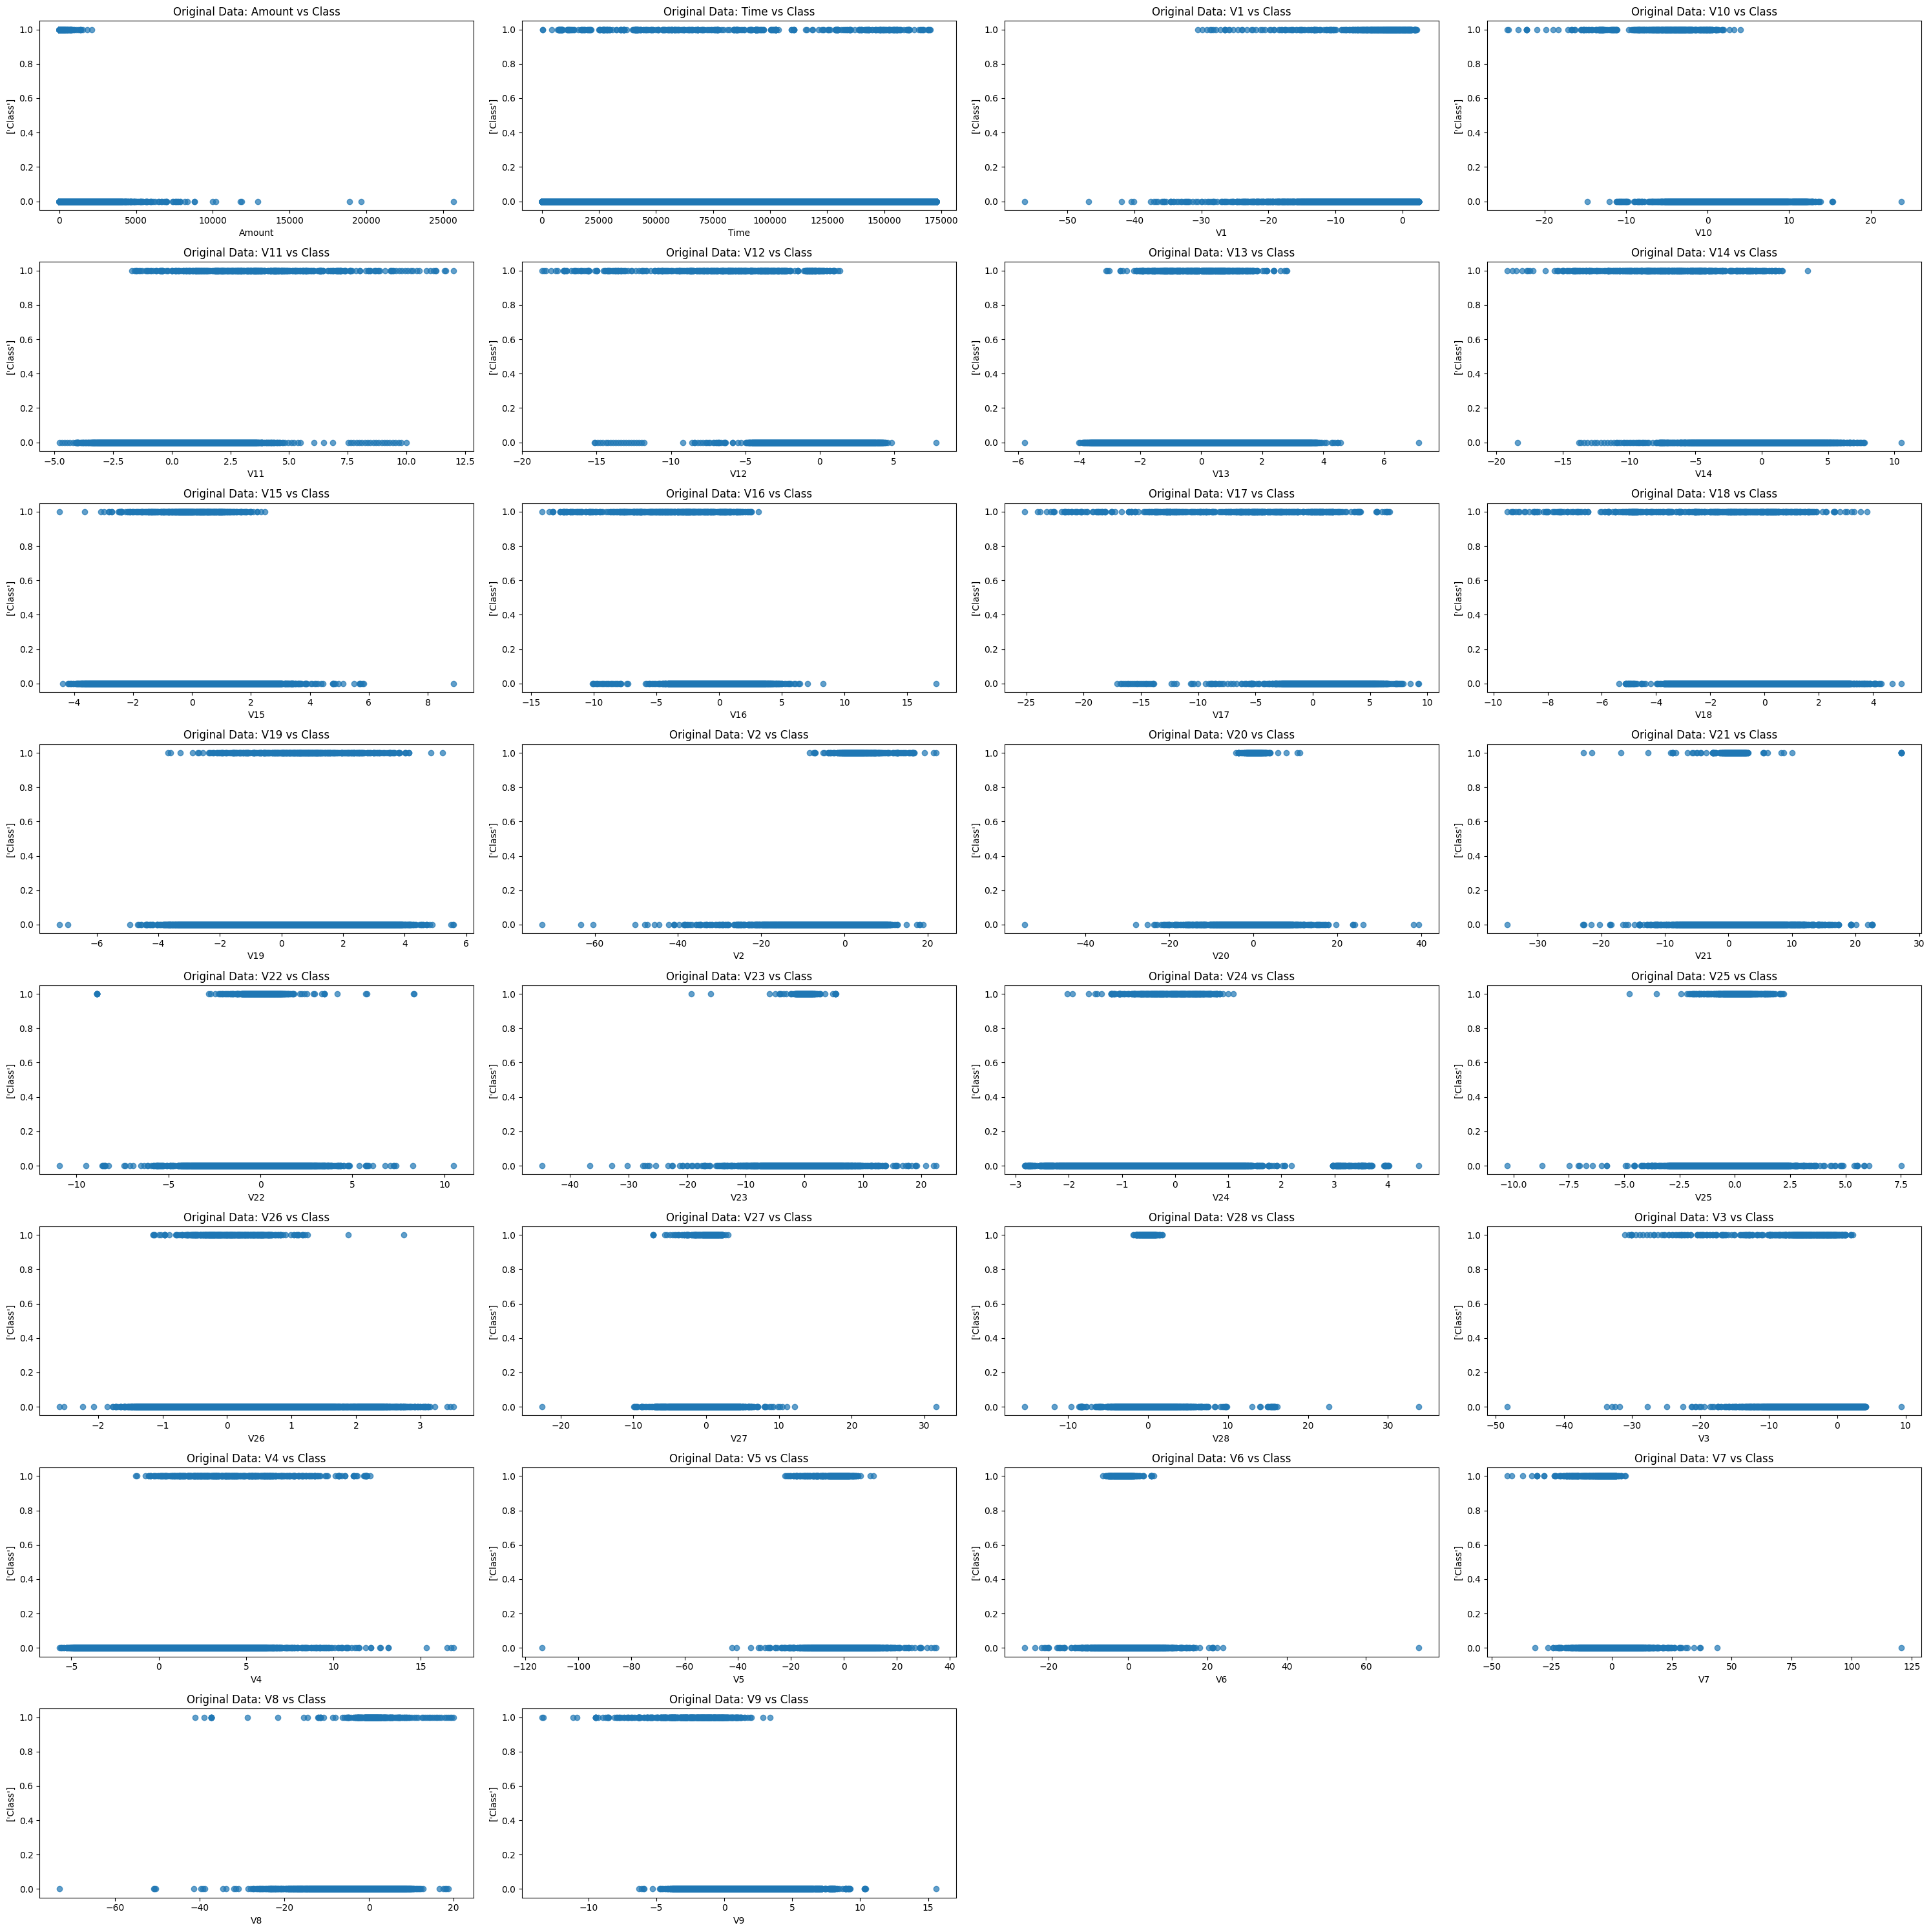

In [4]:
def plot_feature_pairs(target, data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(30, 30))
    
    # Counter for subplot index
    n_cols = 4
    n_rows = 8
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        plt.subplot(n_rows ,n_cols, i+1)
        
        # Scatter plot colored by labels if provided
        if color_labels is not None:
            plt.scatter(data[feature_names[i]], data[target], 
                        c=color_labels, cmap='viridis', alpha=0.7)
        else:
            plt.scatter(data[feature_names[i]], data[target], alpha=0.7)
        
        plt.xlabel(feature_names[i])
        plt.ylabel(target)
        plt.title(f'{title_prefix}{feature_names[i]} vs Class')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()


# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(target, df, feature_names, title_prefix='Original Data: ')
## Class – binary label: 0 = genuine ; 1 = fraud

In [5]:
df = df.drop(['Class_Label'], axis=1)
correlation_matrix = df.corr(method='pearson').round(1)
print(correlation_matrix)

        Time   V1   V2   V3   V4   V5   V6   V7   V8   V9  ...  V21  V22  V23  \
Time     1.0  0.1 -0.0 -0.4 -0.1  0.2 -0.1  0.1 -0.0 -0.0  ...  0.0  0.1  0.1   
V1       0.1  1.0  0.0 -0.0 -0.0  0.0 -0.0 -0.0 -0.0 -0.0  ... -0.0 -0.0  0.0   
V2      -0.0  0.0  1.0  0.0 -0.0  0.0  0.0  0.0 -0.0  0.0  ... -0.0  0.0  0.0   
V3      -0.4 -0.0  0.0  1.0  0.0 -0.0  0.0  0.0 -0.0  0.0  ...  0.0 -0.0 -0.0   
V4      -0.1 -0.0 -0.0  0.0  1.0 -0.0 -0.0 -0.0  0.0  0.0  ... -0.0 -0.0  0.0   
V5       0.2  0.0  0.0 -0.0 -0.0  1.0  0.0  0.0  0.0  0.0  ... -0.0  0.0 -0.0   
V6      -0.1 -0.0  0.0  0.0 -0.0  0.0  1.0  0.0 -0.0  0.0  ...  0.0 -0.0  0.0   
V7       0.1 -0.0  0.0  0.0 -0.0  0.0  0.0  1.0  0.0  0.0  ... -0.0 -0.0 -0.0   
V8      -0.0 -0.0 -0.0 -0.0  0.0  0.0 -0.0  0.0  1.0  0.0  ...  0.0  0.0  0.0   
V9      -0.0 -0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  0.0 -0.0 -0.0   
V10      0.0  0.0 -0.0  0.0  0.0 -0.0  0.0 -0.0 -0.0 -0.0  ...  0.0 -0.0  0.0   
V11     -0.2  0.0  0.0  0.0 

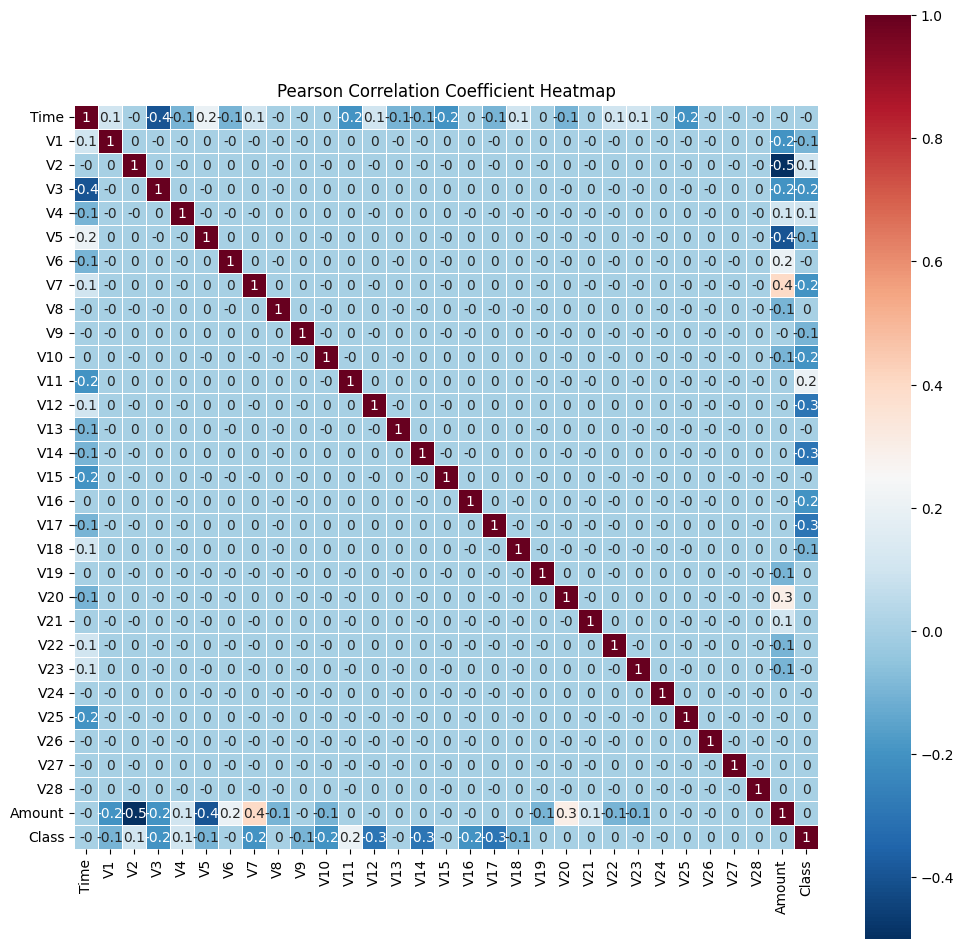

In [6]:
plt.figure(figsize=(12, 12)) # Adjust the figure size as needed
sns.heatmap(correlation_matrix, 
            xticklabels=correlation_matrix.columns, 
            yticklabels=correlation_matrix.columns, 
            cmap='RdBu_r', # Color map (RdBu_r is a good choice for correlation)
            annot=True, # Add the correlation values as annotations
            linewidth=0.5, # Add lines between cells
            square=True) # Force cells to be square

plt.title('Pearson Correlation Coefficient Heatmap')
plt.show()

In [7]:

# Assuming you want correlations relative to a specific target variable, e.g., 'target_col'
target_correlation = correlation_matrix['Class'].sort_values(ascending=False)

# Filter for strong correlations (absolute value > 0.5)
impactful_variables = target_correlation[abs(target_correlation) > 0.1]

print("Impactful variables based on a |r| > 0.5 threshold:")
print(impactful_variables)

Impactful variables based on a |r| > 0.5 threshold:
Class    1.0
V11      0.2
V3      -0.2
V7      -0.2
V10     -0.2
V16     -0.2
V12     -0.3
V14     -0.3
V17     -0.3
Name: Class, dtype: float64


Summary